# Continuous housing investment with frictions: EGM(FUES) vs NEGM(FUES)

In [1]:
import warnings
warnings.filterwarnings('ignore', message='.*IProgress.*')

import numpy as np
import sys, os, time

REPO_ROOT = os.path.abspath('../../..')
sys.path.insert(0, REPO_ROOT)
os.chdir(REPO_ROOT)
os.environ['FUES_RETURN_GRIDS'] = '1'

from examples.durables.solve import solve
from examples.durables.horses.simulate import (
    simulate_lifecycle, evaluate_euler_c, evaluate_euler_h,
)
from examples.durables.outputs import (
    setup_nb_style,
    FilteredStdout, get_timing,
    print_solve_summary, build_comparison_row,
    nb_plot_adjuster_comparison, nb_plot_adjuster_egm,
    nb_plot_keeper_egm, nb_plot_keeper_policy,
    plot_euler_histogram, plot_lifecycle,
    compute_euler_stats,
    generate_vertical_comparison,
    generate_cohort_table,
    nb_plot_value_functions,
)
from IPython.display import Markdown

setup_nb_style()
SYNTAX = 'examples/durables/mod/separable'
print('Ready')

Ready


## 2. Solve

In [2]:
OVERRIDES = dict(
    setting_overrides={
        'store_cntn': 1, 'N_wage': 4,
        'n_w': 900, 'n_a': 900, 'n_h': 900, 
    },
    calib_overrides={
        't0': 20, 'tau': 0.07
    },
)

labels = {'FUES': 'EGM(FUES)', 'NEGM': 'NEGM(FUES)'}
results = {}
real_stdout = sys.stdout
for method in ['FUES', 'NEGM']:
    print(f'{labels[method]}', flush=True)
    t0 = time.time()
    sys.stdout = FilteredStdout(real_stdout)
    try:
        _mo = {('adjuster_cons', 'cntn_to_dcsn_mover', 'upper_envelope'): method}
        nest, grids = solve(
            SYNTAX, method_overrides=_mo,
            verbose=False, progress='bar',
            **OVERRIDES)
    finally:
        sys.stdout = real_stdout
    elapsed = time.time() - t0
    timing = get_timing(nest)
    results[method] = {
        'nest': nest, 'grids': grids,
        'timing': timing, 'elapsed': elapsed,
    }

print_solve_summary(results)

## 3. Adjuster policies

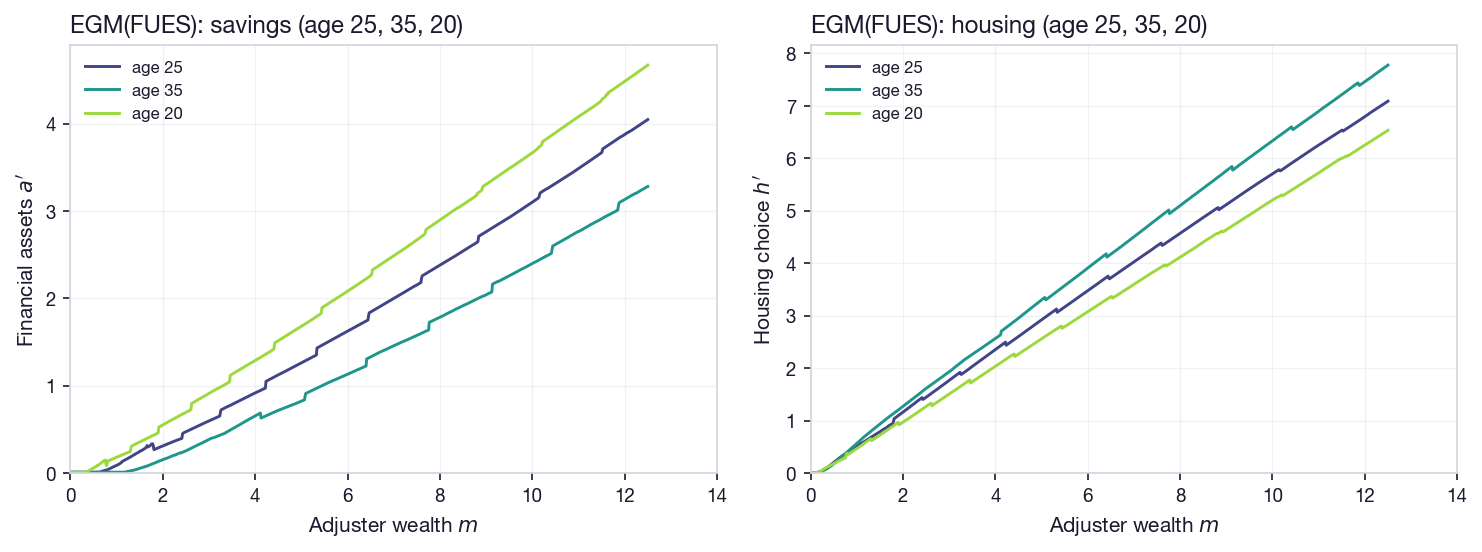

In [3]:
fig = nb_plot_adjuster_comparison(
    results, results['FUES']['grids'],
    plot_t=[25, 35, 20], methods_filter=['FUES'], i_z=0)

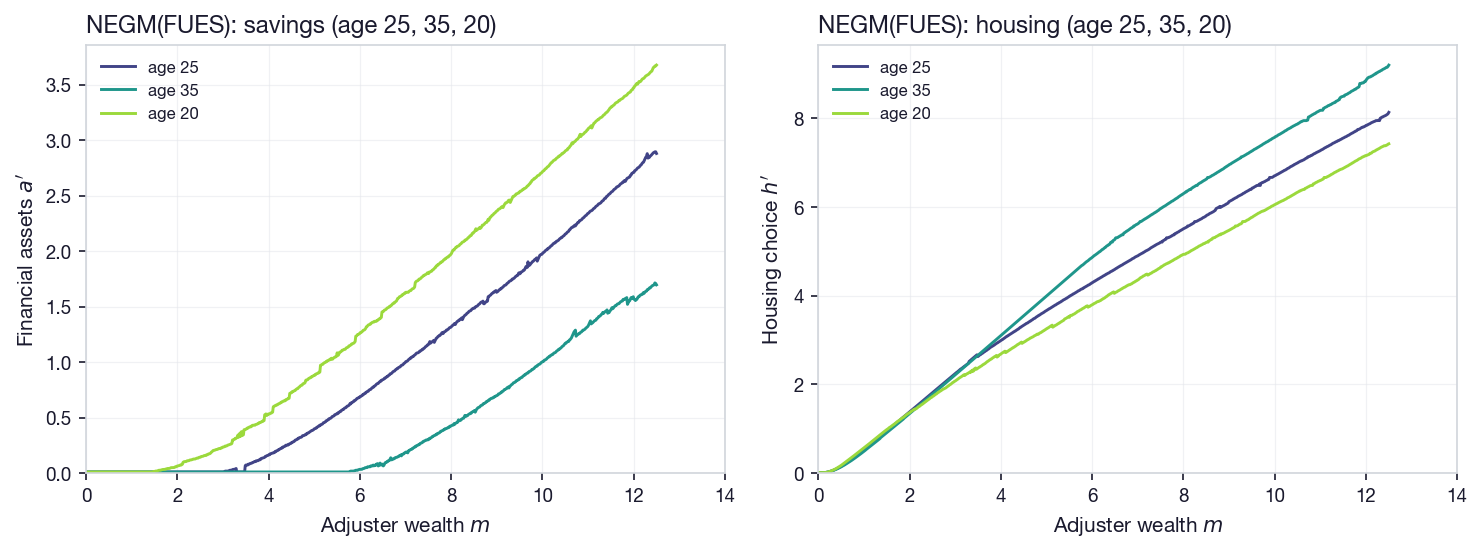

In [4]:
fig = nb_plot_adjuster_comparison(
    results, results['NEGM']['grids'],
    plot_t=[25, 35, 20], methods_filter=['NEGM'], i_z=2)

#fig = nb_plot_value_functions(
#    results, results['FUES']['grids'], plot_t=67)


## 4. Adjuster EGM grid

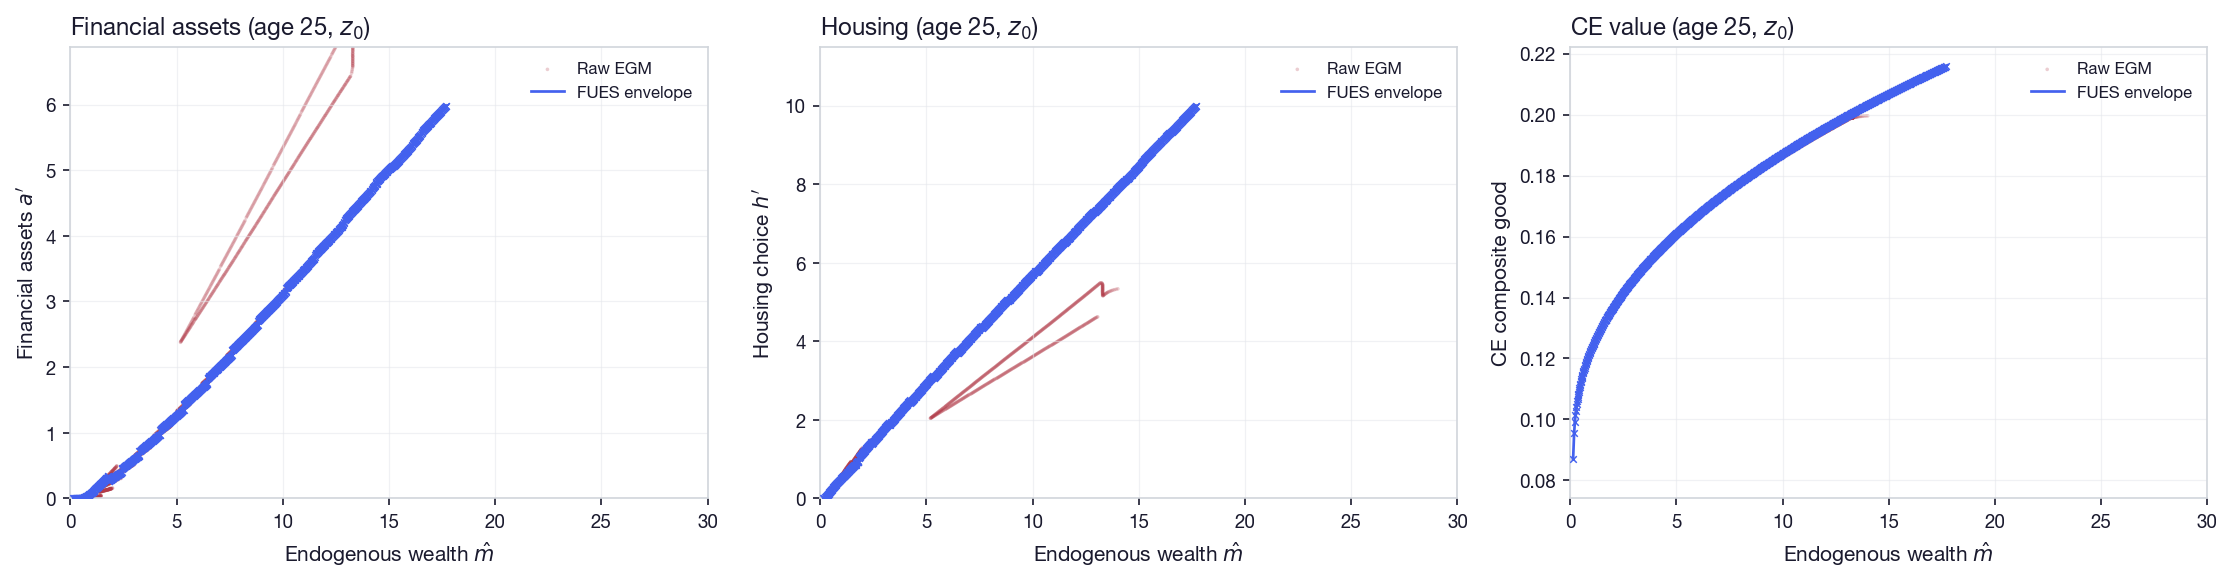

In [6]:
fig = nb_plot_adjuster_egm(
    results['FUES']['nest'],
    results['FUES']['grids'], plot_t=25, xlim =30, i_z=0)

In [7]:
# ── Interactive plotly (zoom/pan to inspect dense crossings) ──
try:
    from examples.durables.outputs import nb_plot_adjuster_egm_interactive
    fig_a, fig_h, fig_v = nb_plot_adjuster_egm_interactive(
        results['FUES']['nest'], results['FUES']['grids'], plot_t=42, i_z=0)
    fig_a.show()
    fig_h.show()
    fig_v.show()
except Exception as e:
    print(f'Interactive plots skipped: {e}')

## 5. Keeper policies

  age 25, z=0: m_clean[0]=0.138623, len=955
  age 25, z=1: m_clean[0]=0.140113, len=898
  age 35, z=0: m_clean[0]=0.140057, len=945
  age 35, z=1: m_clean[0]=0.140762, len=896
  age 55, z=0: m_clean[0]=0.139885, len=838
  age 55, z=1: m_clean[0]=0.140607, len=848


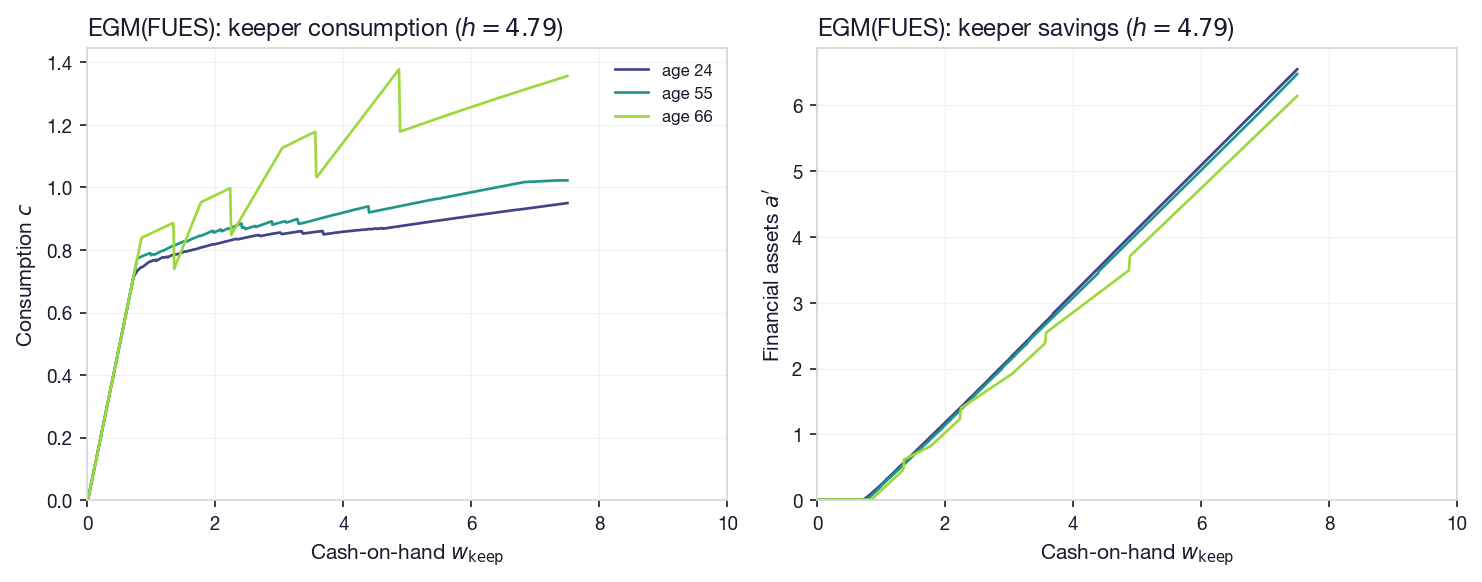

In [ ]:
fig = nb_plot_keeper_policy(results, results['FUES']['grids'],
                           plot_t=[24, 55, 66], methods_filter=['FUES'], xlim=10, i_z=3)

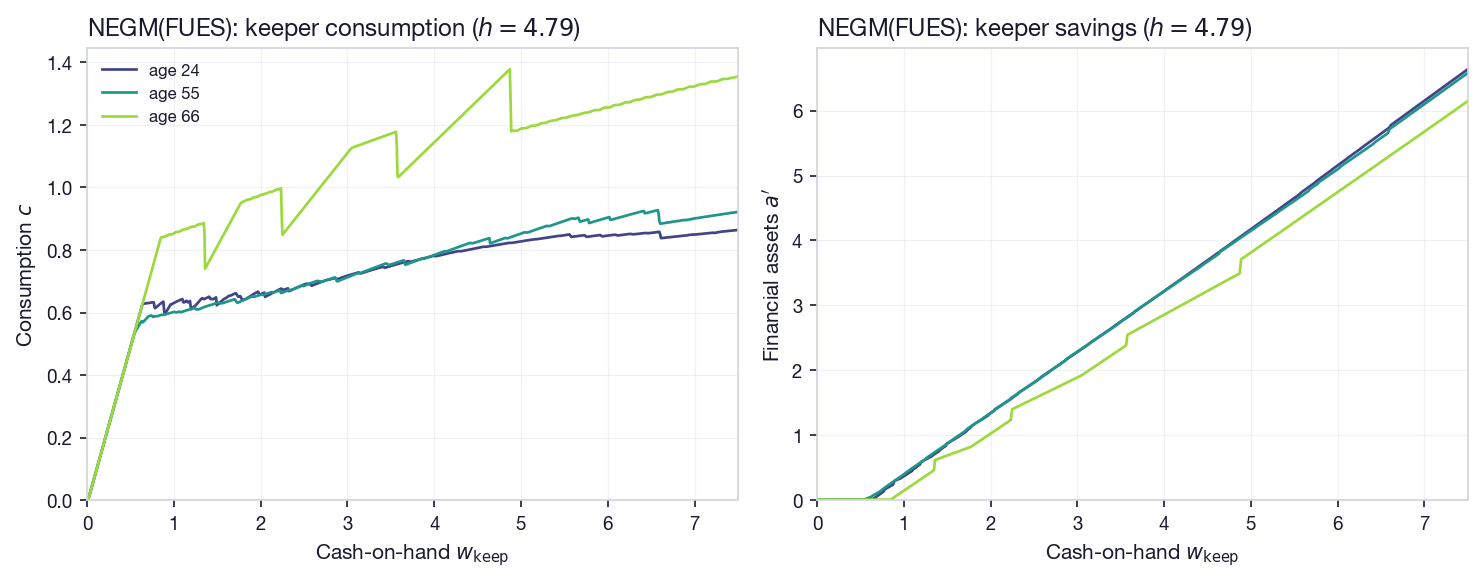

In [9]:
fig = nb_plot_keeper_policy(results, results['NEGM']['grids'],
                           plot_t=[24, 55, 66], methods_filter=['NEGM'])

## 6. Euler equation errors

In [10]:
euler_results = {}

for method in ['FUES', 'NEGM']:
    r = results[method]
    sim_data = simulate_lifecycle(r['nest'], r['grids'], N=10_000, seed=21, init_dispersion=2)       
    euler_c = evaluate_euler_c(sim_data, r['nest'], r['grids'])
    euler_h = evaluate_euler_h(sim_data, r['nest'], r['grids'])
    euler_results[method] = {
        'euler_c': euler_c, 'euler_h': euler_h, 'euler': euler_c,
        'stats_c': compute_euler_stats(euler_c, sim_data['discrete']),
        'stats_h': compute_euler_stats(euler_h, sim_data['discrete']),
        'stats': compute_euler_stats(euler_c, sim_data['discrete']),
        'sim_data': sim_data,
    }

print('Simulation complete (N = 10,000)')

Simulation complete (N = 10,000)


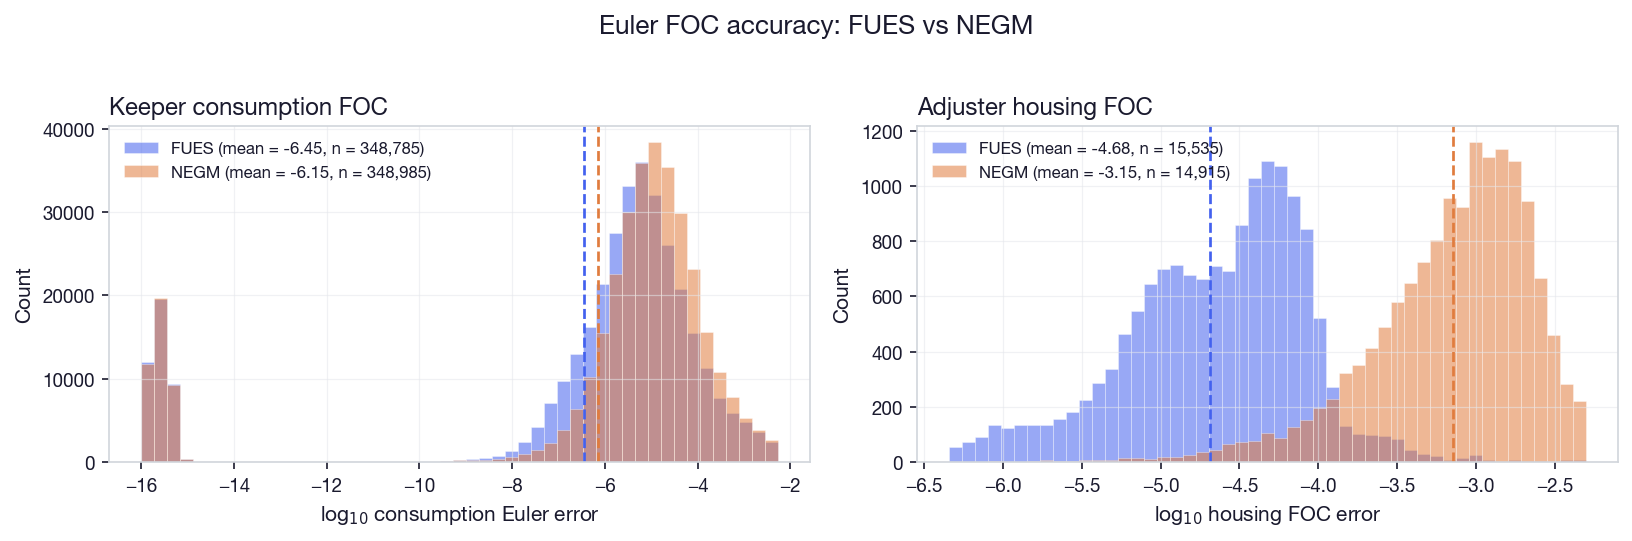

In [11]:
fig = plot_euler_histogram(euler_results)

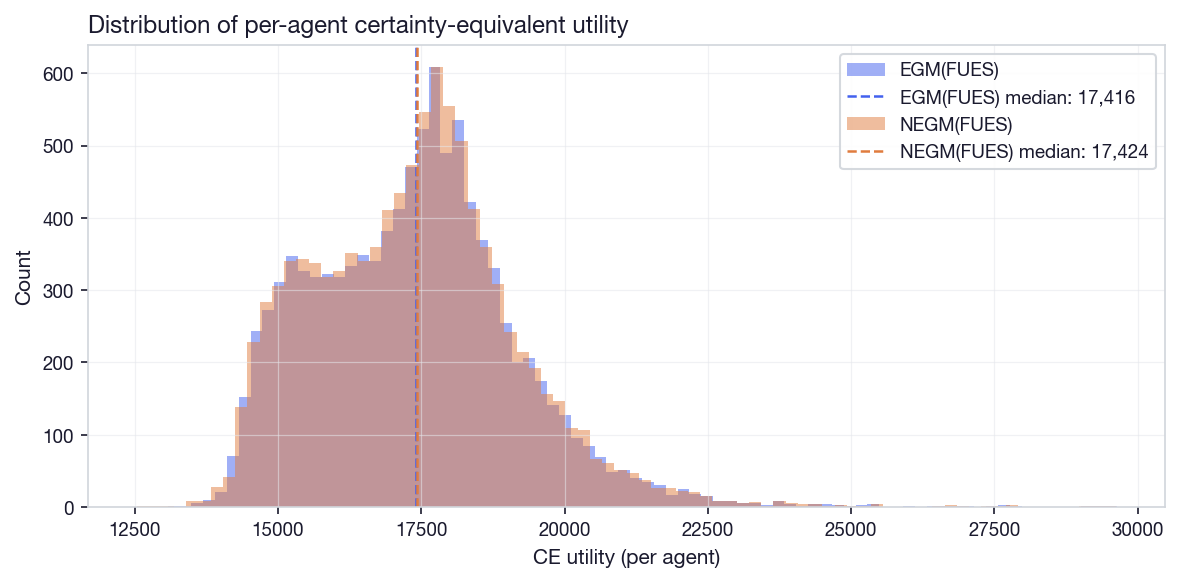

In [12]:
# ── Per-agent CE utility histogram ──
import matplotlib.pyplot as plt

_st = results['FUES']['nest']['periods'][0]['stages']['keeper_cons']
_rho = float(_st.calibration.get('gamma_c', _st.calibration.get('rho', 2.0)))
_norm = 1.0 / float(_st.settings['normalisation'])
_labels = {'FUES': 'EGM(FUES)', 'NEGM': 'NEGM(FUES)'}
_colors = {'FUES': '#4361ee', 'NEGM': '#e07c3e'}

fig, ax = plt.subplots(1, 1, figsize=(8, 4))
for method in ['FUES', 'NEGM']:
    npv = euler_results[method]['sim_data']['npv_utility']
    valid = npv[np.isfinite(npv) & (npv != 0)]
    inner = (1.0 - _rho) * valid
    ce = np.where(inner > 0, inner ** (1.0 / (1.0 - _rho)), np.nan) * _norm
    ce = ce[np.isfinite(ce)]
    ax.hist(ce, bins=80, alpha=0.5, label=_labels[method], color=_colors[method])
    ax.axvline(np.median(ce), color=_colors[method], ls='--', lw=1.2,
               label=f'{_labels[method]} median: {np.median(ce):,.0f}')

ax.set_xlabel('CE utility (per agent)')
ax.set_ylabel('Count')
ax.set_title('Distribution of per-agent certainty-equivalent utility')
ax.legend(fontsize=9)
fig.tight_layout()
plt.show()

## 7. Comparison of aggregates

In [13]:
rows = [build_comparison_row(m, results, euler_results)
        for m in ['FUES', 'NEGM']]
Markdown(generate_vertical_comparison(
    rows, caption='EGM(FUES) vs NEGM(FUES)'))




### EGM(FUES) vs NEGM(FUES)

| | **EGM(FUES)** | **NEGM(FUES)** |
|:---|:---:|:---:|
| **Timing** |  |  |
| Keeper (ms/period) | 652 | 645 |
| Adjuster (ms/period) | 52 | 102 |
| Total (ms/period) | 2338 | 2415 |
| **Euler errors ($\log_{10}$)** |  |  |
| Consumption: keeper | -6.45 | -6.15 |
| Consumption: adjuster | -11.97 | -11.57 |
| Consumption: all | -6.68 | -6.37 |
| Housing: adjuster | -4.68 | -3.15 |
| **Simulation** |  |  |
| CE utility | 17,079.85 | 17,077.23 |
| Mean consumption ($) | 62,213 | 62,211 |
| Mean fin. assets ($) | 68,952 | 68,909 |
| Mean housing ($) | 249,605 | 249,668 |
| Adjustment rate (%) | 19.3 | 19.4 |

## 8. Lifecycle profiles

Lifecycle plot saved to _nb_plots/FUES/simulation/lifecycle.png
EGM(FUES)


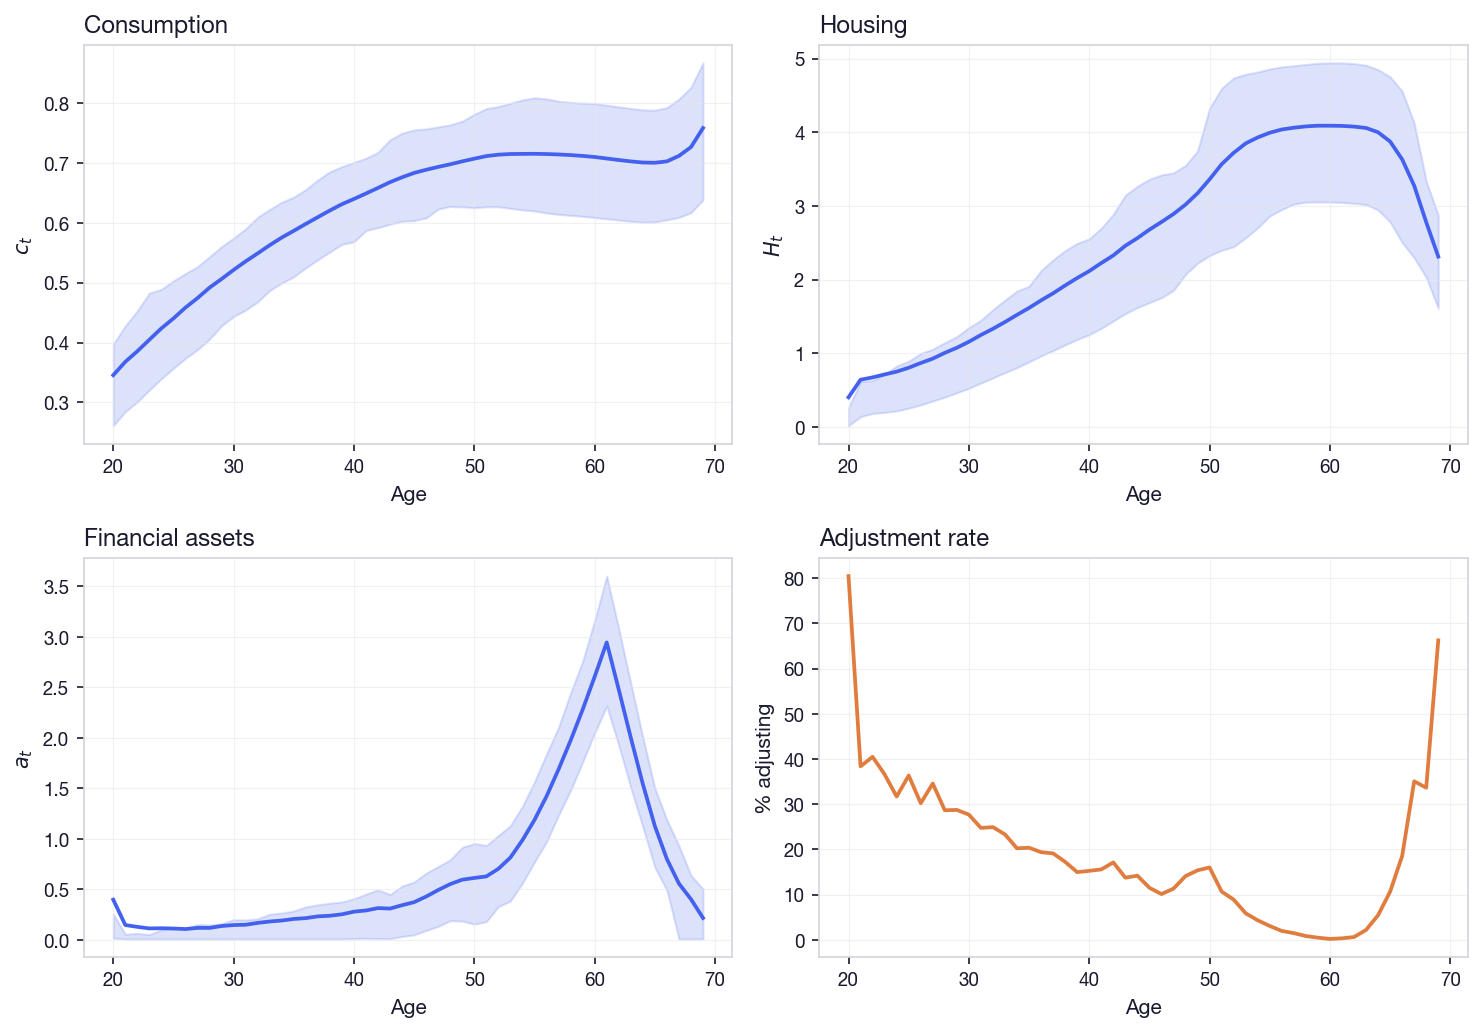

Lifecycle plot saved to _nb_plots/NEGM/simulation/lifecycle.png
NEGM(FUES)


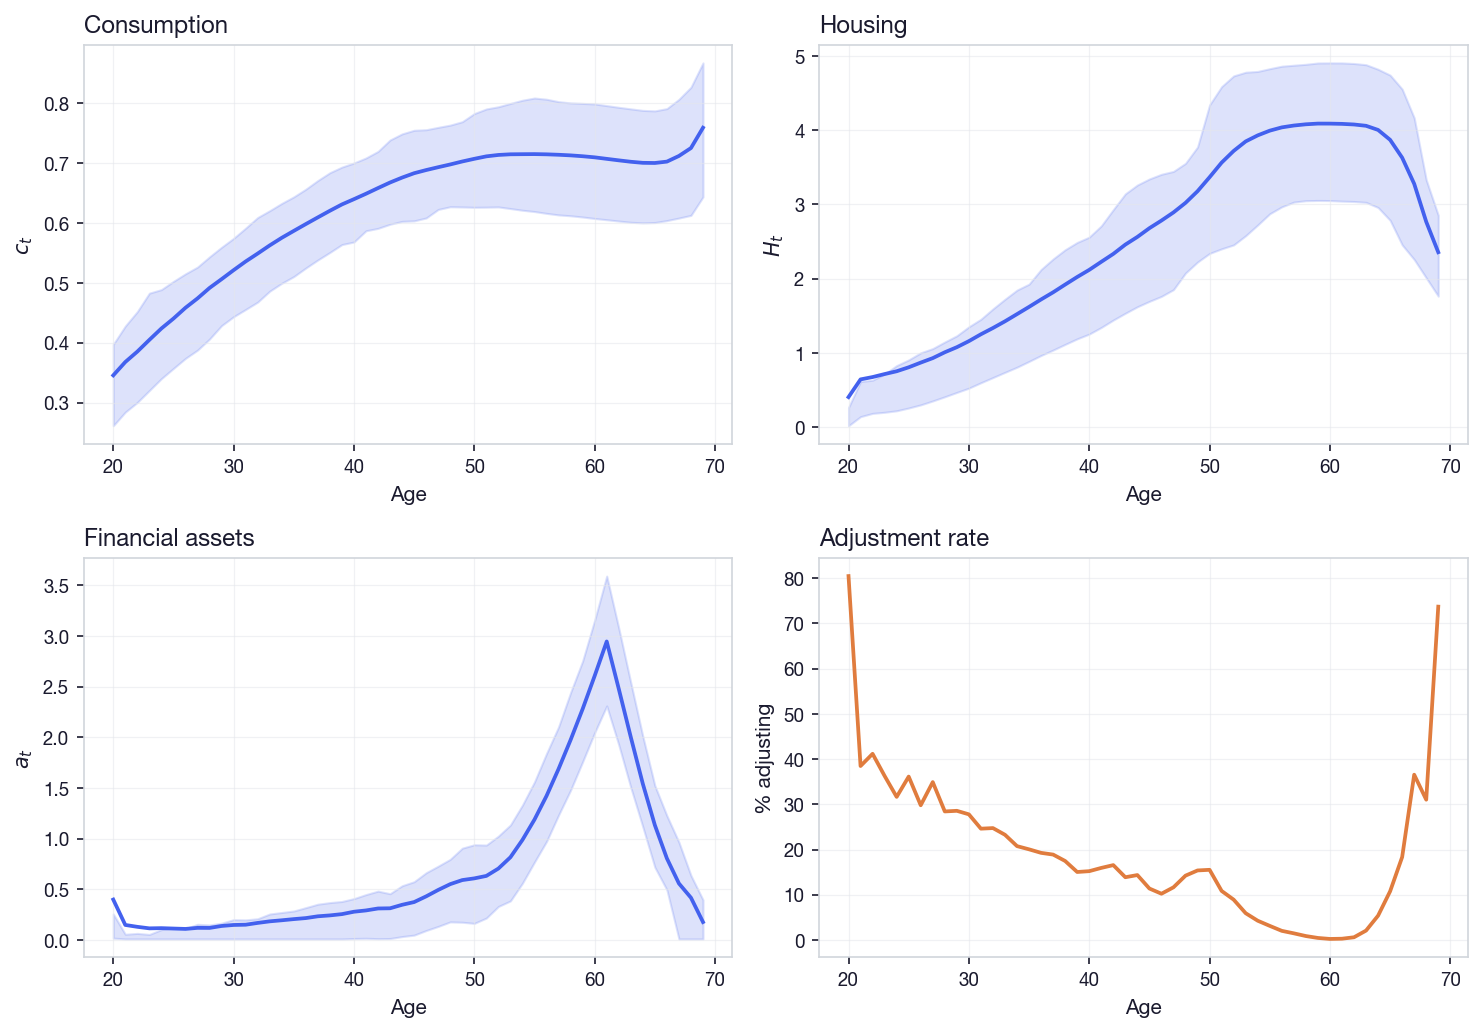

In [14]:
from IPython.display import Image, display

for method in ['FUES', 'NEGM']:
    er = euler_results[method]
    r = results[method]
    plot_lifecycle(er['sim_data'], er['euler'], r['nest'],
                   output_dir=f'_nb_plots/{method}')
    path = f'_nb_plots/{method}/simulation/lifecycle.png'
    if os.path.exists(path):
        print(f'{labels[method]}')
        display(Image(path))

In [15]:
_st0 = results['FUES']['nest']['periods'][0]['stages']['keeper_cons']
_t0 = int(_st0.calibration['t0'])
_T = int(_st0.settings['T'])
_norm = 1.0 / float(_st0.settings['normalisation'])
labels = {'FUES': 'EGM(FUES)', 'NEGM': 'NEGM(FUES)'}

for method in ['FUES', 'NEGM']:
    sd = euler_results[method]['sim_data']
    tbl = generate_cohort_table(sd, _t0, _T, _norm)
    display(Markdown(f'**{labels[method]}**\n\n{tbl}'))

**EGM(FUES)**

| Age | $\bar{c}$ | SD($c$) | $\bar{a}$ | SD($a$) | $\bar{H}$ | SD($H$) |
|:---|---:|---:|---:|---:|---:|---:|
| 20–24 | 38,543.54 | 12,189.03 | 18,124.61 | 59,303.18 | 63,774.66 | 104,578.41 |
| 25–29 | 47,419.26 | 10,745.81 | 11,945.58 | 23,958.64 | 93,754.07 | 96,741.30 |
| 30–34 | 54,885.68 | 9,911.87 | 16,828.96 | 23,386.65 | 133,824.04 | 96,175.35 |
| 35–39 | 60,930.60 | 9,616.46 | 23,016.78 | 27,651.00 | 181,961.12 | 101,925.27 |
| 40–44 | 65,836.18 | 9,676.98 | 30,838.15 | 34,487.97 | 233,941.48 | 112,226.98 |
| 45–49 | 69,328.24 | 10,066.83 | 48,954.89 | 46,001.54 | 290,931.12 | 125,985.81 |
| 50–54 | 71,263.17 | 11,209.64 | 75,026.40 | 57,261.01 | 368,640.22 | 142,290.77 |
| 55–59 | 71,398.29 | 12,551.64 | 171,094.94 | 79,243.09 | 405,339.67 | 143,690.57 |
| 60–64 | 70,525.24 | 12,842.80 | 231,541.55 | 96,027.46 | 406,313.76 | 143,820.49 |
| 65–69 | 72,002.73 | 13,949.18 | 62,144.25 | 55,029.28 | 317,572.42 | 134,292.03 |

**NEGM(FUES)**

| Age | $\bar{c}$ | SD($c$) | $\bar{a}$ | SD($a$) | $\bar{H}$ | SD($H$) |
|:---|---:|---:|---:|---:|---:|---:|
| 20–24 | 38,541.77 | 12,190.69 | 18,153.63 | 59,310.30 | 63,757.39 | 104,559.70 |
| 25–29 | 47,416.09 | 10,745.36 | 11,951.36 | 23,948.24 | 93,773.72 | 96,738.04 |
| 30–34 | 54,887.91 | 9,911.49 | 16,889.40 | 23,428.95 | 133,819.80 | 96,162.46 |
| 35–39 | 60,934.97 | 9,609.12 | 23,050.83 | 27,705.50 | 181,971.89 | 101,903.10 |
| 40–44 | 65,832.12 | 9,681.25 | 30,810.01 | 34,461.47 | 234,001.80 | 112,234.33 |
| 45–49 | 69,331.37 | 10,070.83 | 48,810.34 | 45,997.95 | 291,104.26 | 126,037.06 |
| 50–54 | 71,262.81 | 11,206.14 | 74,990.23 | 57,151.87 | 368,629.00 | 142,197.23 |
| 55–59 | 71,389.32 | 12,549.57 | 171,089.41 | 79,294.25 | 405,294.47 | 143,869.37 |
| 60–64 | 70,509.19 | 12,844.46 | 231,555.18 | 96,128.16 | 406,305.75 | 143,769.60 |
| 65–69 | 72,007.51 | 13,969.23 | 61,791.97 | 55,957.51 | 318,024.54 | 133,796.89 |